## Distribución normal multivariada

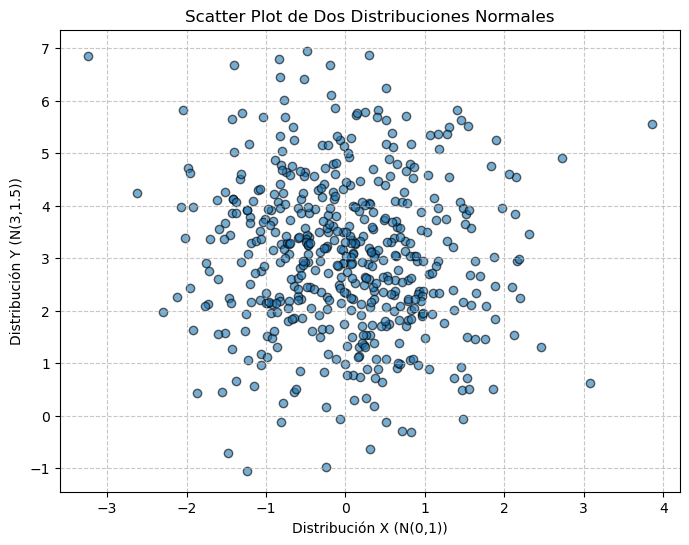

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Semilla para reproducibilidad
np.random.seed(42)

# Generar dos distribuciones normales
x = np.random.normal(loc=0, scale=1, size=500)   # media 0, desviación estándar 1
y = np.random.normal(loc=3, scale=1.5, size=500) # media 3, desviación estándar 1.5

# Crear scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.6, edgecolor='k')

# Personalización
plt.title('Scatter Plot de Dos Distribuciones Normales')
plt.xlabel('Distribución X (N(0,1))')
plt.ylabel('Distribución Y (N(3,1.5))')
plt.grid(True, linestyle='--', alpha=0.7)

# Mostrar gráfico
plt.show()


# Distribución Normal Multivariada

La **distribución normal multivariada** es la generalización de la distribución normal a más de una variable aleatoria.  
En el caso bivariado (dos variables), describe cómo se comportan simultáneamente dos variables **continuas** que pueden estar **correlacionadas** entre sí.

---

## 📘 Definición matemática

Una distribución normal multivariada en dos dimensiones se define por:

- Un **vector de medias**:

  $$
  \mu = 
  \begin{bmatrix}
  \mu_X \\
  \mu_Y
  \end{bmatrix}
  $$

- Una **matriz de covarianzas**:

  $$
  \Sigma =
  \begin{bmatrix}
  \sigma_X^2 & \text{cov}(X,Y) \\
  \text{cov}(Y,X) & \sigma_Y^2
  \end{bmatrix}
  $$

Donde:
- $\sigma_X^2$ y $\sigma_Y^2$ son las varianzas de cada variable.
- $\text{cov}(X,Y)$ mide cómo se mueven juntas las variables.

Si $\text{cov}(X,Y)=0$, las variables son **independientes**  
Si $\text{cov}(X,Y)\neq 0$, las variables están **correlacionadas** (positiva o negativamente).

---

## 💻 Ejemplo práctico en Python

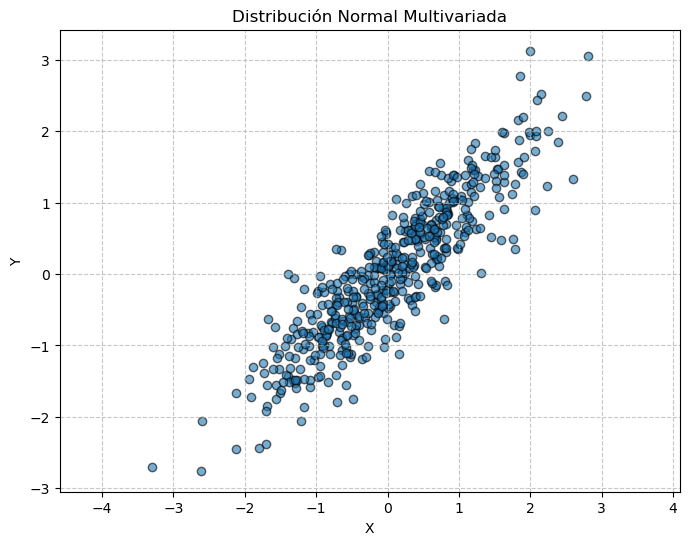

In [7]:

# Parámetros de la distribución
mean = [0, 0]  # medias de X e Y
cov = [[1, 0.9], [0.9, 1]]  # matriz de covarianzas (correlación positiva)

# Muestra aleatoria de una normal bivariada
x, y = np.random.multivariate_normal(mean, cov, 500).T

# Gráfico
plt.figure(figsize=(8,6))
plt.scatter(x, y, alpha=0.6, edgecolor='k')
plt.title('Distribución Normal Multivariada')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True, linestyle='--', alpha=0.7)
plt.axis('equal')
plt.show()


# 🧠 Análisis del Discriminante Lineal (LDA) bajo el supuesto Gaussiano

El **Análisis del Discriminante Lineal (LDA)** parte del supuesto de que **cada clase** sigue una **distribución normal multivariada** con:

- **Distinto vector de medias** $\mu_k$
- **Misma matriz de covarianza** $\Sigma$ para todas las clases

donde $k \in \{1, 2, ..., K\}$ representa las clases.

---

## 📘 Formulación teórica

### 1. Supuesto Gaussiano

Cada clase tiene distribución:

$$
p(x \mid y = k) = \frac{1}{(2\pi)^{d/2} |\Sigma|^{1/2}}
\exp\!\left(-\frac{1}{2}(x - \mu_k)^T \Sigma^{-1}(x - \mu_k)\right)
$$

donde:
- $\mu_k$ = vector de medias de la clase $k$
- $\Sigma$ = matriz de covarianza **común a todas las clases**

---

### 2. Priori y regla de Bayes

Se asume además una probabilidad **a priori** para cada clase:
$$
P(y = k)
$$

Usando la **regla de Bayes**, la probabilidad posterior es proporcional a:

$$
P(y = k \mid x) \propto p(x \mid y = k) \, P(y = k)
$$

---



In [13]:
from sklearn.datasets import fetch_openml
import pandas as pd
from sklearn.model_selection import train_test_split

X, y = fetch_openml("credit-g", as_frame=True, parser="auto", return_X_y=True)
# Dummies y transforma la y
X = pd.get_dummies(X)
y = y == 'good'

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.7, random_state=42)


/Users/antoniomanguart/opt/anaconda3/envs/nuevo_entorno/lib/python3.10/site-packages/sklearn/datasets/_openml.py:301: UserWarning: Multiple active versions of the dataset matching the name credit-g exist. Versions may be fundamentally different, returning version 1.
  warn(


## Entrena un LDA

In [91]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn import linear_model

In [92]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lda", LinearDiscriminantAnalysis())
])
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('lda', LinearDiscriminantAnalysis())])

## Calcula el AUC

In [33]:
from sklearn.metrics import roc_auc_score

In [34]:
predicciones_lda = pipeline.predict_proba(X_test)[:,1]

In [35]:
roc_auc_score(y_score=predicciones_lda, y_true=y_test)

0.7352251407129456

# Comparalo cojn la regresión logistica

In [86]:
model = linear_model.LogisticRegression().fit(X_train, y_train)
predicciones_log = model.predict_proba(X_test)[:,1]
roc_auc_score(y_score=predicciones_log, y_true=y_test)

/Users/antoniomanguart/opt/anaconda3/envs/nuevo_entorno/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.753244215134459

### ¿Cuando usar cada modelo?

# 📊 Cuándo usar cada modelo de clasificación

| Modelo | Cuándo usarlo | Supuestos principales | Comentarios clave |
|:--|:--|:--|:--|
| **KNN (K-Nearest Neighbors)** | 🔹 **Baja dimensionalidad**<br>🔹 **No normalidad**<br>🔹 Relaciones no lineales | - No asume distribución de datos.<br>- Basado en distancia y vecindad local. | Muy intuitivo pero se degrada con muchos features (“maldición de la dimensionalidad”). |
| **LDA (Análisis del Discriminante Lineal)** | 🔹 **Poca data**<br>🔹 **Normalidad por clase**<br>🔹 Covarianza similar entre clases | - Supone normales multivariadas por clase con covarianza común. | Rápido, interpretable y robusto cuando el supuesto se cumple. |
| **Regresión Logística** | 🔹 **Buen intermedio** entre simplicidad y potencia<br>🔹 **Datos medianos o grandes** | - Supone frontera lineal entre clases.<br>- Variables numéricas y categóricas (con dummies). | Excelente punto de partida; base para muchos modelos más complejos. |
| **Perceptrón Multicapa (MLP)** | 🔹 **Dataset complejo o no lineal**<br>🔹 **Muchas variables o patrones difíciles** | - No requiere supuestos de forma o distribución. | Gran capacidad de modelar no linealidades, pero exige tuning y datos abundantes. |

---

💡 **Resumen rápido para recordar:**

- 🧩 **KNN** → pocos features, sin normalidad.  
- 📈 **LDA** → poca data pero estructura gaussiana.  
- ⚖️ **Logística** → equilibrio entre simplicidad y generalidad.  
- 🧠 **MLP** → relaciones complejas, no lineales y mucho dato.


### Aplicación crédito 

In [87]:
df_logistica = pd.DataFrame({
    'y': y_test,
    'predicciones_logistica': predicciones_log,
    'predicciones_lda': predicciones_lda,
    'credit_amount': X_test.credit_amount
})


In [88]:
# Supongamos que tus modelos generan probabilidades
# pred_prob_log y pred_prob_lda son arrays o Series con probabilidad de "buen cliente"
# y_test es binaria: True = buen cliente, False = mal cliente

df = pd.DataFrame({
    'y': y_test,
    'p_log': predicciones_log,
    'p_lda': predicciones_lda,
    'credit_amount': X_test.credit_amount
})

# Definimos cortes (umbral de aprobación)
cortes = np.linspace(0.9, 0.1, 9)  # de 0.9 a 0.1 en pasos de 0.1

tabla_resultados = []

for modelo in ['p_log', 'p_lda']:
    for c in cortes:
        aprobados = df[df[modelo] >= c]
        if len(aprobados) == 0:
            continue

        # Acceptance Rate: proporción de aprobados
        acceptance = len(aprobados) / len(df)

        # Default Rate: proporción de malos entre aprobados
        default_rate = 1 - aprobados['y'].mean()

        # Expected Loss: pérdida esperada monetaria (ponderada por monto)
        monto_total = aprobados['credit_amount'].sum()
        monto_default = aprobados.loc[aprobados['y'] == 0, 'credit_amount'].sum()
        expected_loss = monto_default / monto_total if monto_total > 0 else np.nan

        tabla_resultados.append({
            'Modelo': modelo.replace('p_', '').upper(),
            'Corte': round(c, 2),
            'Acceptance Rate (%)': acceptance * 100,
            'Default Rate (%)': default_rate * 100,
            'Expected Loss (%)': expected_loss * 100
        })

# Convertir a DataFrame
tabla_cortes = pd.DataFrame(tabla_resultados)
tabla_cortes = tabla_cortes.sort_values(['Modelo', 'Corte'], ascending=[True, False])
tabla_cortes.reset_index(drop=True, inplace=True)

tabla_cortes

,Modelo,Corte,Acceptance Rate (%),Default Rate (%),Expected Loss (%)
0,LDA,0.9,41.428571,14.137931,16.829215
1,LDA,0.8,53.428571,17.379679,18.724922
2,LDA,0.7,63.714286,19.058296,22.303557
3,LDA,0.6,67.857143,19.368421,22.389595
4,LDA,0.5,73.428571,20.622568,23.677856
5,LDA,0.4,77.714286,21.875000,25.671841
6,LDA,0.3,82.285714,23.784722,28.555946
7,LDA,0.2,87.000000,25.123153,29.787328
8,LDA,0.1,90.285714,26.265823,30.767027
9,LOG,0.9,32.714286,10.480349,12.021223


In [89]:
cortes_lda = tabla_cortes.query("Modelo == 'LDA'")
cortes_log = tabla_cortes.query("Modelo == 'LOG'")

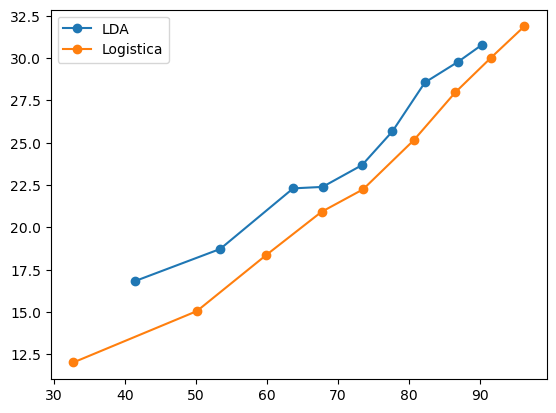

In [90]:
plt.plot(cortes_lda['Acceptance Rate (%)'], cortes_lda['Expected Loss (%)'], marker="o", label="LDA")
plt.plot(cortes_log['Acceptance Rate (%)'], cortes_log['Expected Loss (%)'], marker="o", label="Logistica")
plt.legend()

# Mejorando la logistica

In [ ]:
model = linear_model.LogisticRegression().fit(X_train, y_train)
predicciones_log = model.predict_proba(X_test)[:,1]
roc_auc_score(y_score=predicciones_log, y_true=y_test)